In [1]:
!pip install matplotlib

     ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
     --- ------------------------------------ 0.8/8.1 MB 23.4 MB/s eta 0:00:01
     --- ------------------------------------ 0.8/8.1 MB 23.4 MB/s eta 0:00:01
     ---- ----------------------------------- 0.8/8.1 MB 7.5 MB/s eta 0:00:01
     ------ --------------------------------- 1.2/8.1 MB 7.9 MB/s eta 0:00:01
     ------ --------------------------------- 1.2/8.1 MB 7.9 MB/s eta 0:00:01
     ------ --------------------------------- 1.2/8.1 MB 7.9 MB/s eta 0:00:01
     ------ --------------------------------- 1.2/8.1 MB 7.9 MB/s eta 0:00:01
     ------ --------------------------------- 1.2/8.1 MB 7.9 MB/s eta 0:00:01
     ------ --------------------------------- 1.2/8.1 MB 7.9 MB/s eta 0:00:01
     ------ --------------------------------- 1.4/8.1 MB 3.0 MB/s eta 0:00:03
     -------- ------------------------------- 1.7/8.1 MB 3.4 MB/s eta 0:00:02
     -------- ------------------------------- 1.8/8.1 MB 3.2 MB/s eta


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


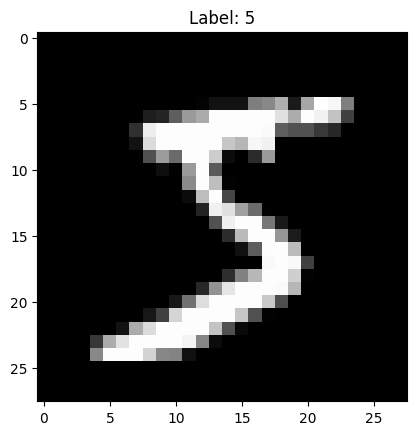

In [4]:
plt.imshow(x_train[0],cmap='gray')
plt.title("Label: " + str(y_train[0]))
plt.show()

In [5]:
x_train=x_train/255.0
x_test=x_test/255.0

In [6]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)
print("New Shape:", x_train.shape)

New Shape: (60000, 28, 28, 1)


In [8]:
model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.9610 - loss: 0.1300
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9871 - loss: 0.0419
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9911 - loss: 0.0282
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9938 - loss: 0.0196
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9950 - loss: 0.0147


In [11]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9907 - loss: 0.0336
Test Accuracy: 0.9907000064849854


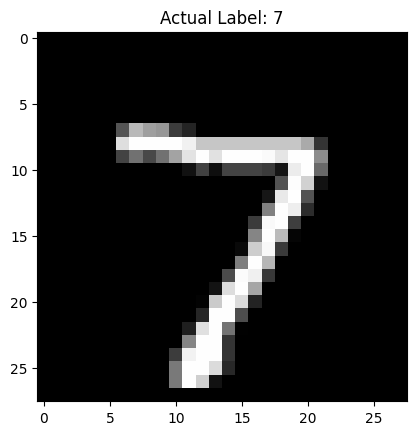

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Predicted Label: 7


In [12]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Actual Label: " + str(y_test[0]))
plt.show()

prediction = model.predict(x_test[0].reshape(1,28,28,1))
print("Predicted Label:", prediction.argmax())